In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
from PIL import Image
import random

In [ ]:
embeddings = np.load('/content/drive/MyDrive/copydays-ndid/Sumanth/clip_embeddings.npy')
paths = np.load('/content/drive/MyDrive/copydays-ndid/Sumanth/clip_paths.npy', allow_pickle=True)

print('Embeddings shape:', embeddings.shape)
print('Paths shape:', paths.shape)


Embeddings shape: (1491, 512)
Paths shape: (1491,)


In [ ]:
# pca resuces number of dimensions making it faster to process
# keeps most useful information
# removes noise and redundancy
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings)
print('PCA shape:', embeddings_pca.shape)

PCA shape: (1491, 50)


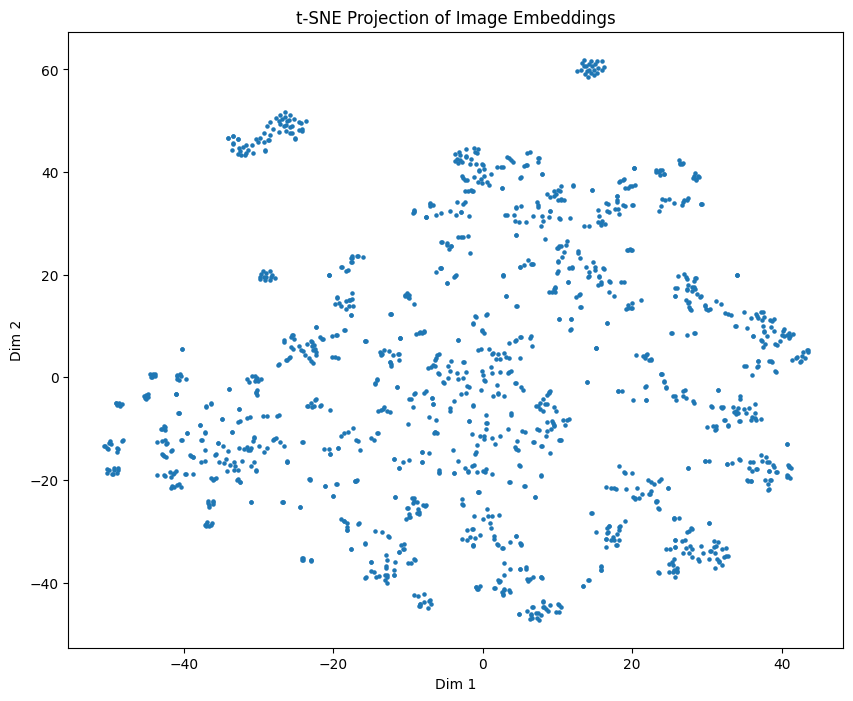

In [ ]:
# tsne visulaizes in 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)
plt.title('t-SNE Projection of Image Embeddings')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.show()

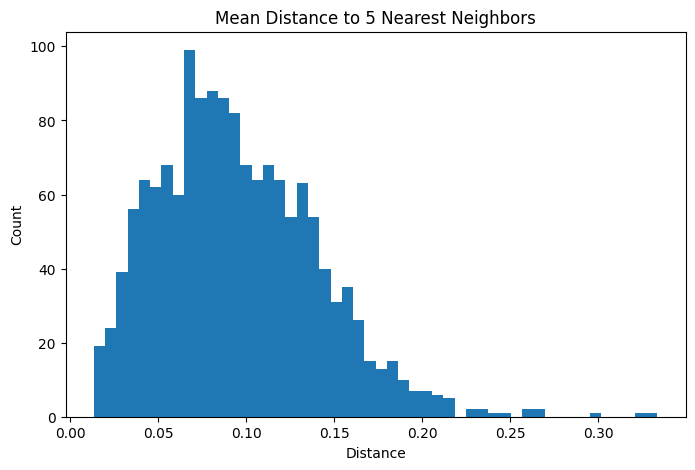

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5, metric='cosine').fit(embeddings)
dists, idxs = nbrs.kneighbors(embeddings)
mean_dists = dists.mean(axis=1)

plt.figure(figsize=(8,5))
plt.hist(mean_dists, bins=50)
plt.title('Mean Distance to 5 Nearest Neighbors')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.show()

In [ ]:
# shows top k similar images to i
def show_neighbors(i, k=5):
    q = embeddings[i].reshape(1,-1)
    sims = 1 - np.linalg.norm(embeddings - q, axis=1)
    top = np.argsort(sims)[-k:][::-1]

    plt.figure(figsize=(15,3))
    for j, idx in enumerate(top):
        img = Image.open(paths[idx])
        plt.subplot(1, k, j+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'sim={sims[idx]:.2f}')
    plt.show()

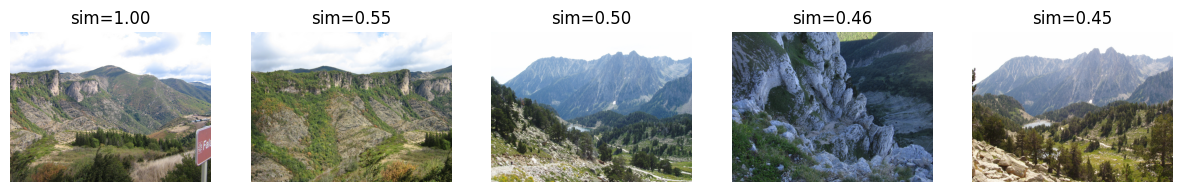

In [ ]:
show_neighbors(random.randint(0, len(embeddings)-1))


In [ ]:
# selecting data that is top 5% disimilar
# these are bad or mislabelled data
threshold = np.percentile(mean_dists, 95)
outliers = np.where(mean_dists > threshold)[0]

print('Number of outliers:', len(outliers))


Number of outliers: 75


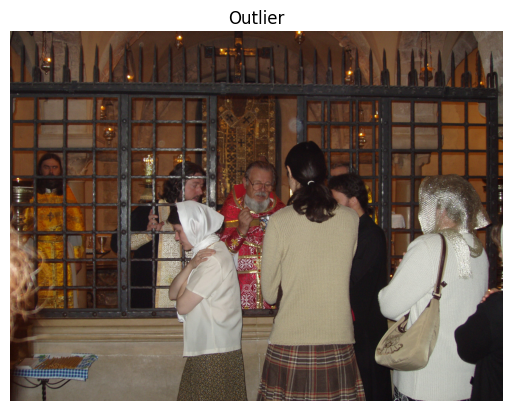

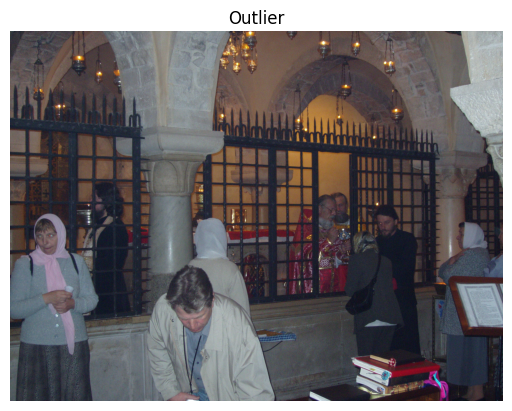

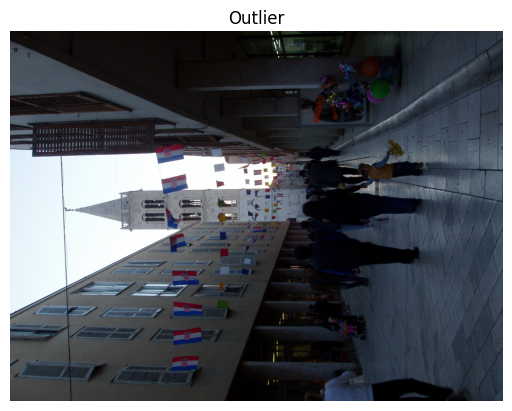

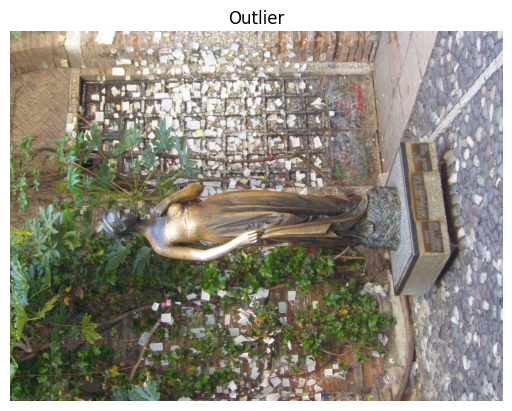

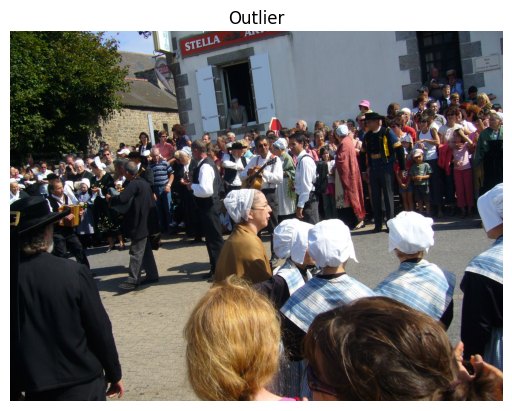

In [ ]:
for idx in outliers[:5]:
    img = Image.open(paths[idx])
    plt.imshow(img)
    plt.axis('off')
    plt.title('Outlier')
    plt.show()